In [731]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

import shap
from jaxsr import BasisLibrary, SymbolicRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay
import xgboost as xgb
import math





## 1. Data Cleaning and Processing

### 1.1 Data loading and format conversion

In [732]:
# Load the dataset
absorb = pd.read_csv("abs.csv")
absorb.head()

cat = pd.read_csv("cat.csv")
cat.head()

gain_70 = pd.read_csv("gain_70.csv")
gain_70.head()  

new_rows = absorb.columns[2:-3]
df = pd.DataFrame()
df["well"]=new_rows

# Converting table into long format and time into hours
absorb["Time"] = pd.to_timedelta(absorb["Time"]).dt.total_seconds()/3600
well_cols = absorb.columns[absorb.columns.str.match(r"^[A-H](?:[1-9]|1[0-2])$")]
abs_long = absorb[["Time", *well_cols]].melt(id_vars="Time", var_name="well", value_name="OD")
abs_long = abs_long.merge(cat[["well", "media_type", "function"]], on="well", how="left")

### 1.2 Blank wells check (if they drifts over time)

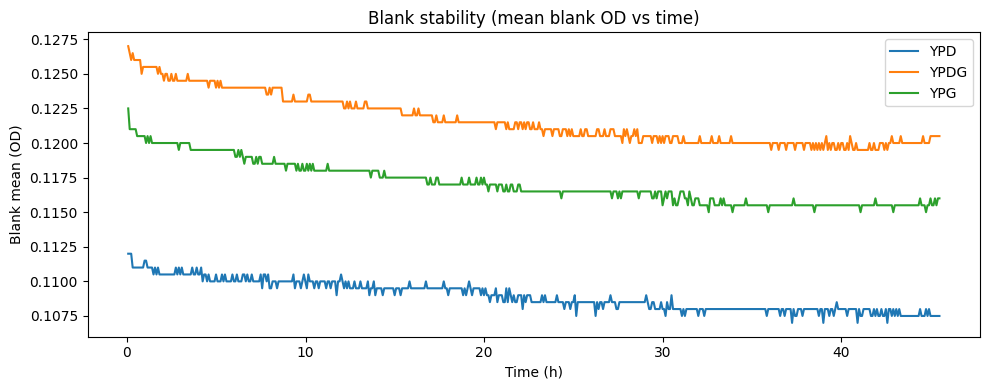

In [733]:
blank_only = abs_long[abs_long["well"].isin(abs_long[abs_long["function"].str.lower().eq("blank")]["well"].unique())].copy()

blank_curve = (blank_only
              .groupby(["media_type","Time"], as_index=False)["OD"]
              .mean()
              .rename(columns={"OD":"blank_mean"}))

# plot blank means
plt.figure(figsize=(10,4))
for mt, g in blank_curve.groupby("media_type"):
    plt.plot(g["Time"], g["blank_mean"], label=mt)
plt.xlabel("Time (h)"); plt.ylabel("Blank mean (OD)")
plt.title("Blank stability (mean blank OD vs time)")
plt.legend()
plt.tight_layout()
plt.show()



Blank stability plot

The blank wells show a small, monotonic decrease in OD over time  with no oscillations or sudden shifts. The magnitude of this drift is negligible compared to biological growth signals , indicating the plate reader measurements are stable and early OD differences primarily reflect biological activity rather than instrumental artifacts.

### 1.3 Data Standarization (Baseline Subctraction + Blank Subtraction)

Baseline subtraction is essential in cell growth modeling to remove non-biological background noise (e.g., media absorbance, instrument fluctuations) from raw measurement data. 

In [734]:
# Baseline correction for instrumental noise:
abs_long = abs_long.sort_values(["well", "Time"])
abs_long["OD_basecorr"] = abs_long["OD"] - abs_long.groupby("well")["OD"].transform("first")

# Blank subtraction 
blank_ref = (
    abs_long[abs_long["function"]=="blank"]
    .groupby(["media_type", "Time"], as_index=False)["OD"]
    .mean()
    .rename(columns={"OD": "OD_blank"})
)

abs_long = abs_long.merge(blank_ref, on=["media_type", "Time"], how="left")
abs_long["OD"] = abs_long["OD"] - abs_long["OD_blank"]



### 1.4 Abnormal growth detection

First, any well with OD below −0.01 was flagged, since negative optical density is not physically meaningful and usually indicates measurement error.

Second, detect sharp up–down oscillations in the growth curve. Real biological growth should be smooth, so sudden slope flips with large magnitude likely indicate artifacts such as bubbles, pipetting errors, or plate reader noise.

To determine what counts as “unusually large,” we used median + 6×MAD as the threshold.

MAD (Median Absolute Deviation) measures typical variability in a robust way. Unlike standard deviation, it is not distorted by extreme outliers.

This means our threshold reflects what most wells look like, and only wells that behave extremely differently from the rest of the plate are flagged.

Using 6×MAD makes the method conservative, so we avoid over-flagging normal biological variation.

Overall, this approach combines biological reasoning (growth should be smooth) with robust statistics (MAD-based threshold), making the bad-well detection reliable and defensible.

,well,min_OD,max_abs_jump,max_spike,flag_negative,flag_spike,flag_any
39,E11,0.0060,0.0660,0.0890,False,True,True
41,E2,0.0055,0.0585,0.0755,False,True,True
44,E5,0.0055,0.0530,0.0820,False,True,True
47,E9,0.0010,0.0590,0.0790,False,True,True
66,G7,-0.0035,0.0510,0.0810,False,True,True
75,H4,-0.0060,0.0520,0.0930,False,True,True
77,H6,0.0010,0.0655,0.1165,False,True,True
79,H8,0.0040,0.0460,0.0750,False,True,True


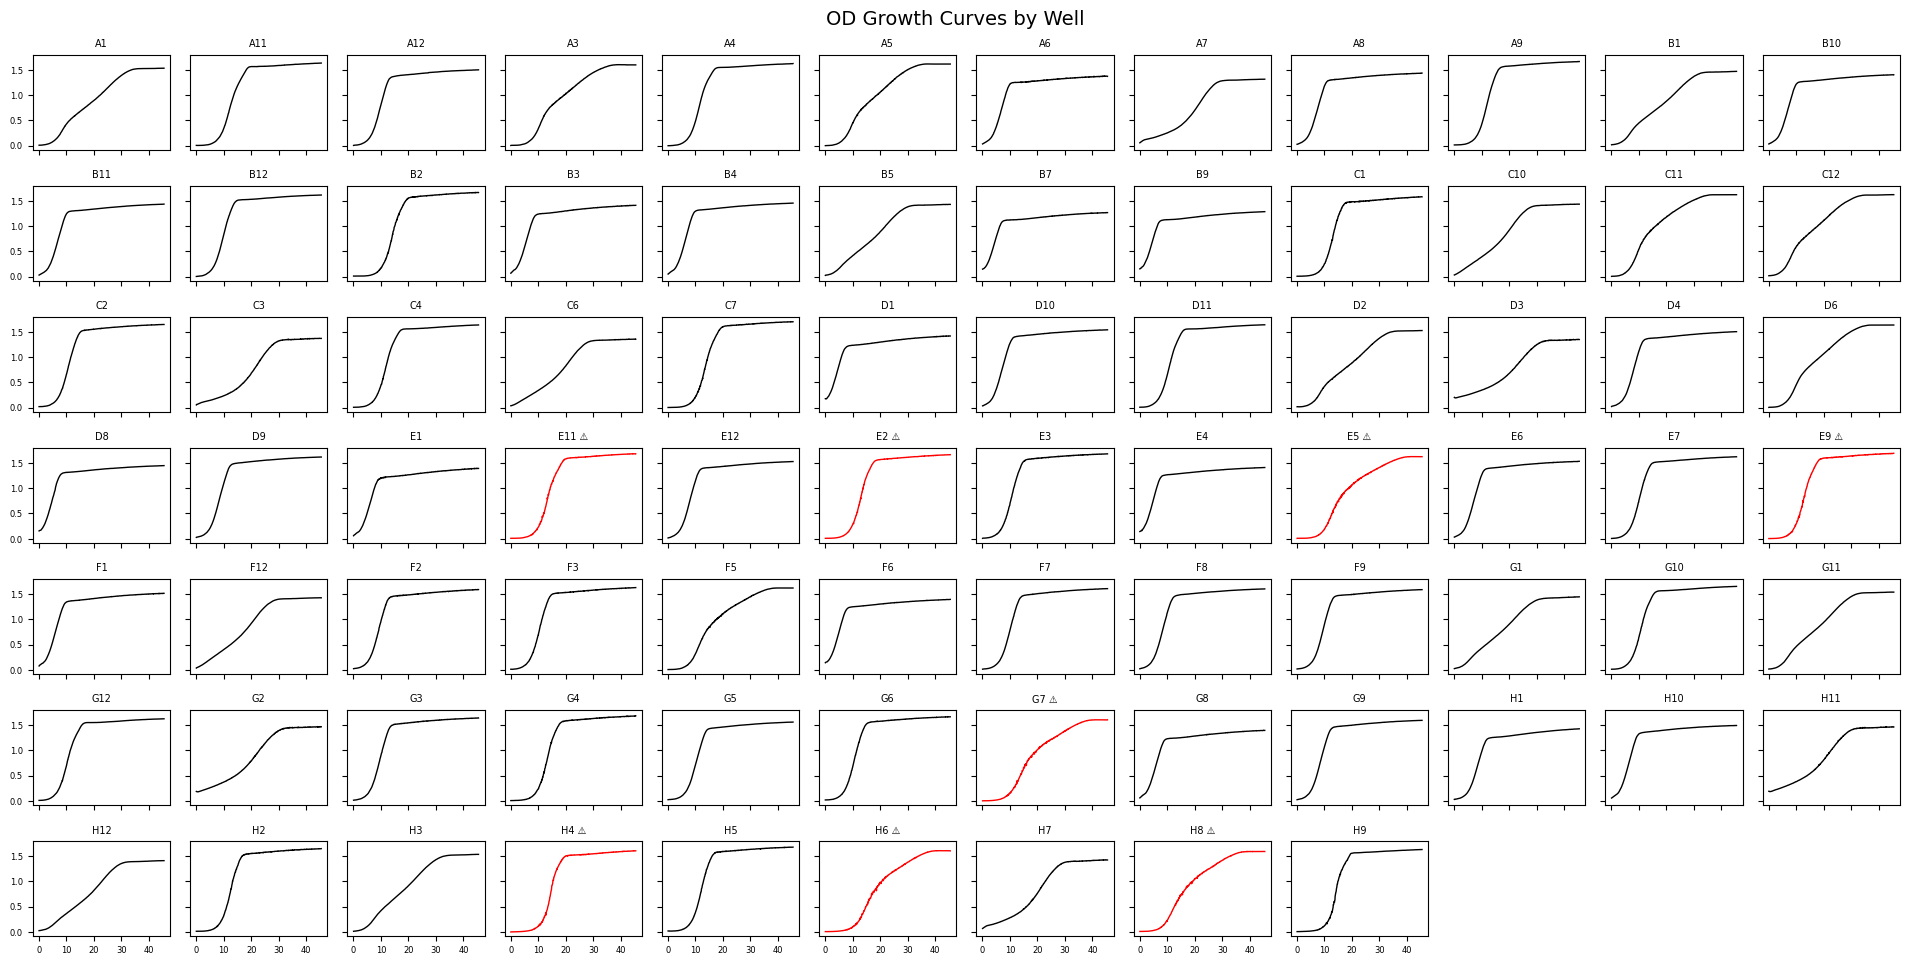

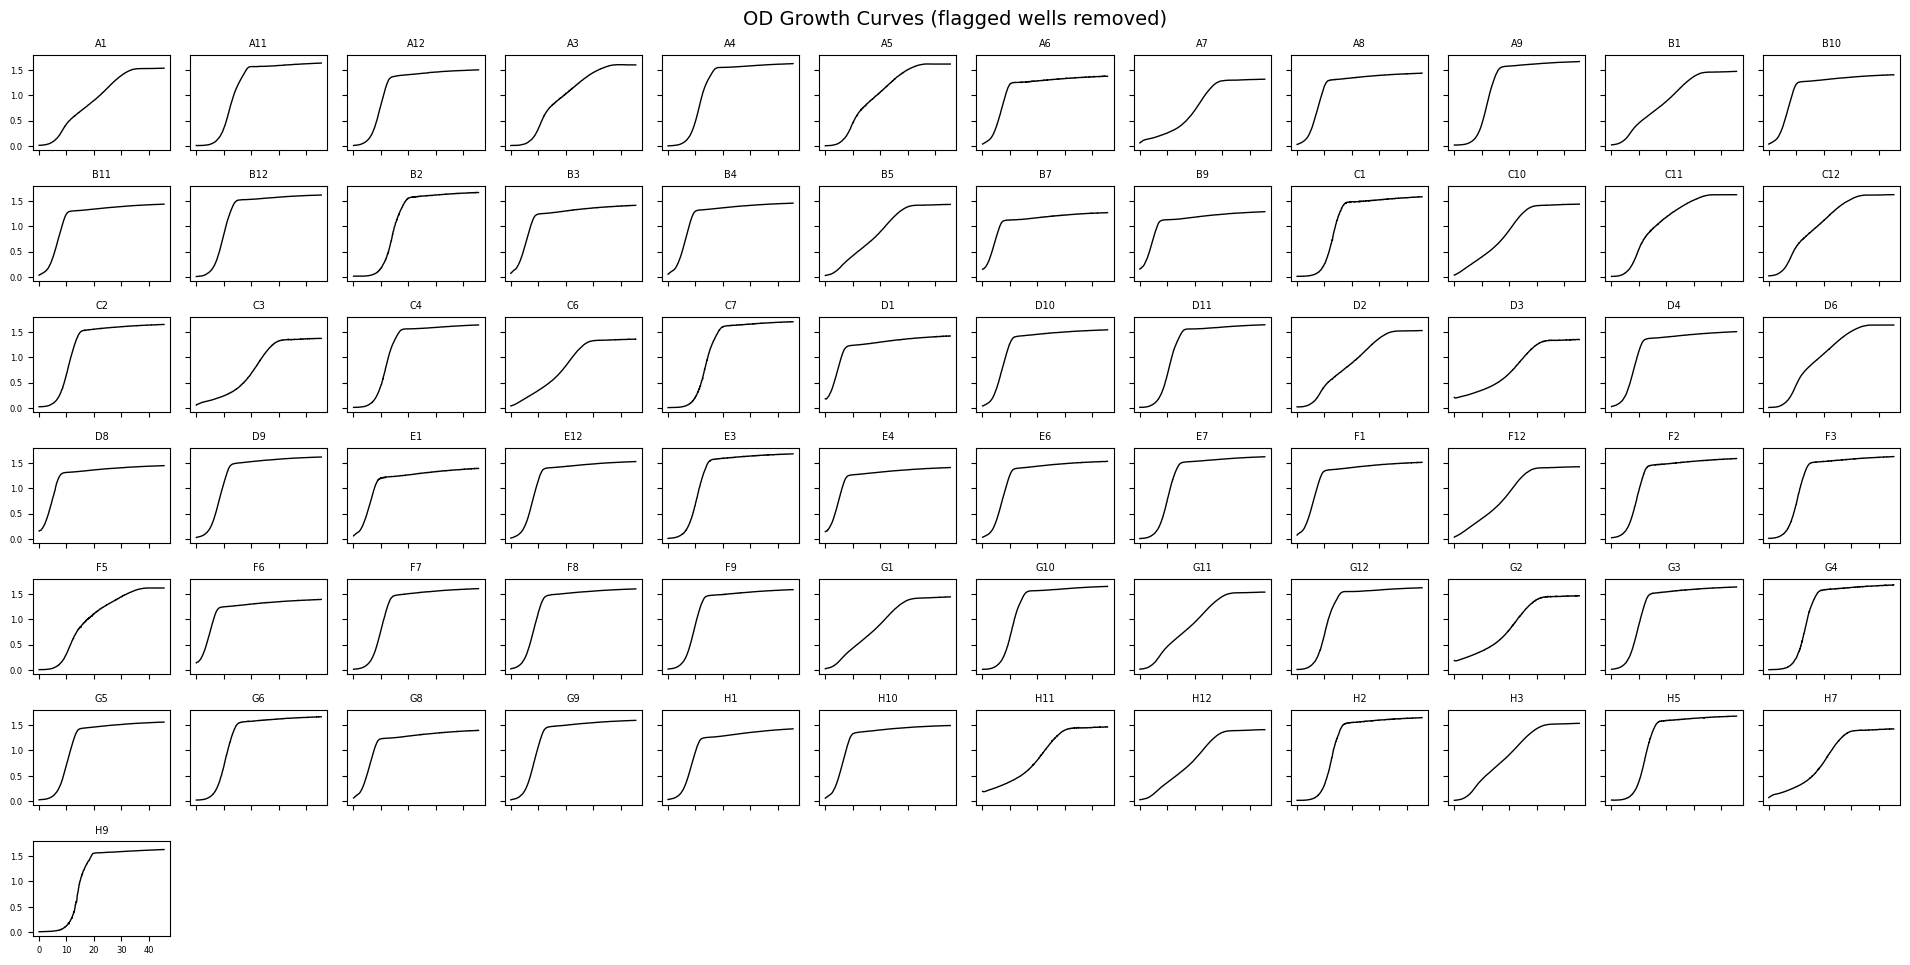

In [735]:
# Flag bad wells (negative or large jumps)
abs_long = abs_long[~abs_long["function"].isin(["blank", "standard"])].copy()

# Sort
abs_long = abs_long.sort_values(["well", "Time"]).copy()

# First difference
abs_long["dOD"] = abs_long.groupby("well")["OD"].diff()

# Spike score: look for sign flips (up then down, or down then up)
abs_long["dOD_next"] = abs_long.groupby("well")["dOD"].shift(-1)
abs_long["spike_score"] = (
    abs_long["dOD"].abs() + abs_long["dOD_next"].abs()
) * ((abs_long["dOD"] * abs_long["dOD_next"]) < 0)  # True when sign flips

bad = (abs_long.groupby("well")
       .apply(lambda g: pd.Series({
           "min_OD": g["OD"].min(),
           "max_abs_jump": g["dOD"].abs().max(),
           "max_spike": g["spike_score"].max()
       }))
       .reset_index())

# Negative OD rule
bad["flag_negative"] = bad["min_OD"] < -0.01

# Spike threshold (robust)
med = bad["max_spike"].median()
mad = np.median(np.abs(bad["max_spike"] - med))
thr_spike = med + 6*mad if mad > 0 else bad["max_spike"].quantile(0.99)

bad["flag_spike"] = bad["max_spike"] > thr_spike

# Final flagged
bad["flag_any"] = bad["flag_negative"] | bad["flag_spike"]
display(bad[bad["flag_any"]])

flagged_wells = bad.loc[bad["flag_any"], "well"]

# Remove from cat (so OD_init disappears too)
cat = cat[~cat["well"].isin(flagged_wells)].copy()

# Remove from df (so left merge doesn't reintroduce them)
df = df[~df["well"].isin(flagged_wells)].copy()


# --- Plot 1: show flagged in red ---
wells = sorted(abs_long["well"].unique())
cols = 12
rows = math.ceil(len(wells) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*1.6, rows*1.4), sharex=True, sharey=True)
axes = axes.flatten()

for i, w in enumerate(wells):
    g = abs_long[abs_long["well"] == w]
    ax = axes[i]

    # choose color
    if w in flagged_wells.values:
        color = "red"
        title = f"{w} ⚠"
    else:
        color = "black"
        title = w

    ax.plot(g["Time"], g["OD"], color=color, linewidth=1)
    ax.set_title(title, fontsize=7)
    ax.tick_params(labelsize=6)

# remove unused panels
for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.suptitle("OD Growth Curves by Well", fontsize=14)
plt.tight_layout()
plt.show()
# Remove flagged wells
abs_long_clean = abs_long[~abs_long["well"].isin(flagged_wells)].copy()
abs_long=abs_long_clean


# --- Plot 2: show all wells except flagged ---

wells2 = sorted(abs_long_clean["well"].unique())
cols = 12
rows2 = math.ceil(len(wells2) / cols)

fig, axes = plt.subplots(rows2, cols,
                         figsize=(cols*1.6, rows2*1.4),
                         sharex=True, sharey=True)
axes = axes.flatten()

for i, w in enumerate(wells2):
    g = abs_long_clean[abs_long_clean["well"] == w]
    ax = axes[i]

    ax.plot(g["Time"], g["OD"], color="black", linewidth=1)
    ax.set_title(w, fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.suptitle("OD Growth Curves (flagged wells removed)", fontsize=14)
plt.tight_layout()
plt.show()





### 1.5 Data smoothing (avoid noise by bubbles / instrumental noises)

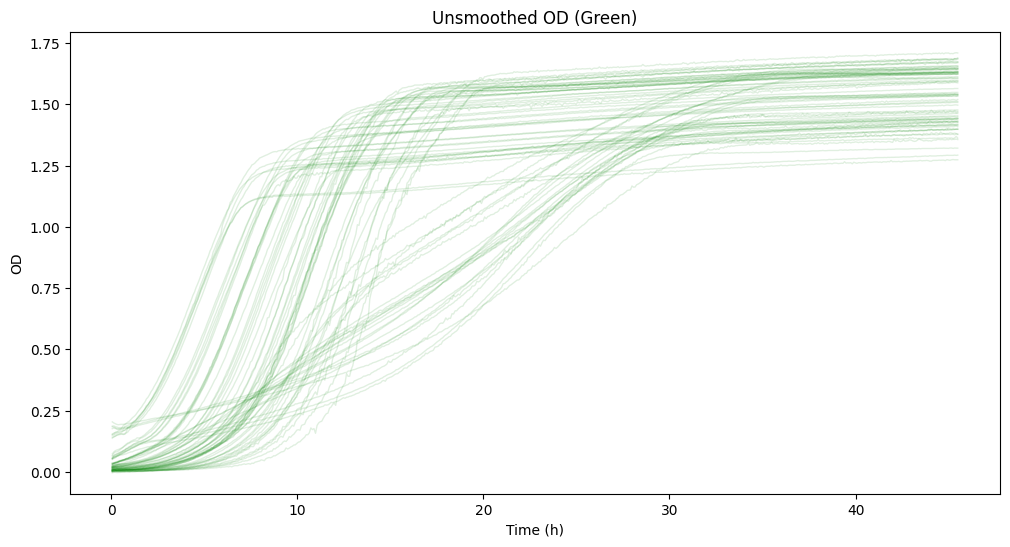

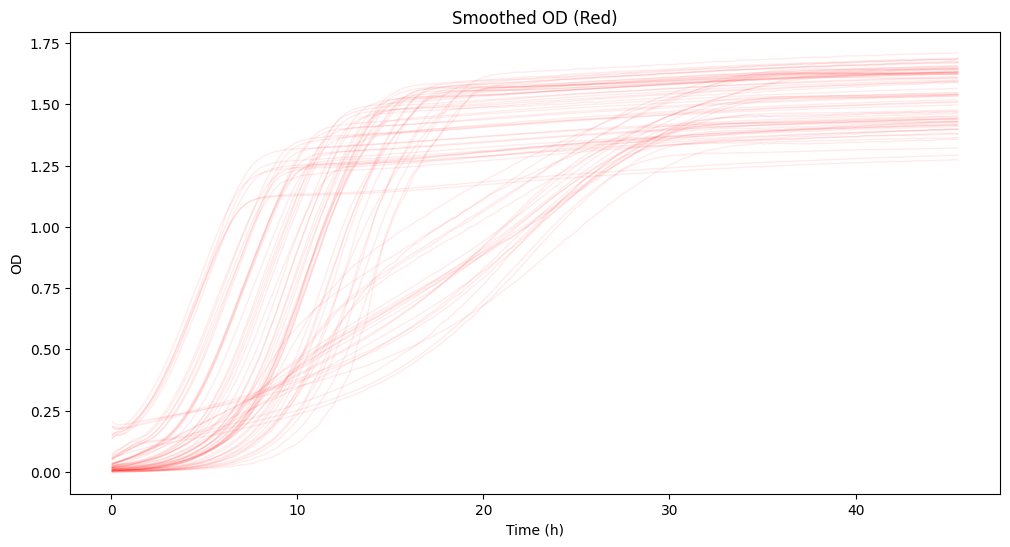

Median noise raw   : 0.00503550010003673
Median noise smooth: 0.0048146815960752945
Noise reduction %  : 4.385234824239692


In [736]:
# Smoothing  per well)
def smooth_group(g):
    g = g.sort_values("Time").copy()
    y = g["OD"].values

    # choose valid window size automatically
    n = len(y)
    if n < 5:
        g["OD_smooth"] = y
        return g

    window = min(11, n if n % 2 == 1 else n-1)
    window = max(window, 5)  # minimum usable
    
    try:
        g["OD_smooth"] = savgol_filter(y, window_length=window, polyorder=3)
    except:
        g["OD_smooth"] = y
        
    return g


# Smooth while keeping columns
abs_long_clean = (
    abs_long_clean
    .sort_values(["well", "Time"])
    .groupby("well")
    .apply(smooth_group)
    .reset_index()
)
abs_long_clean = abs_long_clean.drop(columns=["level_1"], errors="ignore")


#Compare raw corrected vs smoothed for a quick check
plt.figure(figsize=(12, 6))
for _, g in abs_long_clean.groupby("well"):
    plt.plot(g["Time"], g["OD"],"g-", alpha=0.12, lw=1)
plt.xlabel("Time (h)")
plt.ylabel("OD")
plt.title("Unsmoothed OD (Green)")
plt.show()

plt.figure(figsize=(12, 6))
for _, g in abs_long_clean.groupby("well"):
    plt.plot(g["Time"], g["OD_smooth"], "r-", alpha=0.08, lw=1)
plt.xlabel("Time (h)")
plt.ylabel("OD")
plt.title("Smoothed OD (Red)")
plt.show()

# Simple numeric noise check (median std of first differences)
noise_raw = abs_long_clean.groupby("well")["OD"].apply(lambda s: np.nanstd(np.diff(s)))
noise_smooth = abs_long_clean.groupby("well")["OD_smooth"].apply(lambda s: np.nanstd(np.diff(s)))
print("Median noise raw   :", float(np.nanmedian(noise_raw)))
print("Median noise smooth:", float(np.nanmedian(noise_smooth)))
print("Noise reduction %  :", float(100*(1 - np.nanmedian(noise_smooth)/np.nanmedian(noise_raw))))




## 2. Feature Engineering

To transform each OD time-series into model-ready variables, I extract biologically meaningful parameters that describe the early growth phases (lag and exponential). These parameters are motivated by standard sigmoidal growth models such as Gompertz, logistic, and three-phase linear models.

The features I include are:

media_type

OD_init – the initial biomass level at t = 0.

μ_max – the maximum specific growth rate, calculated as the maximum slope of ln(OD) versus time; this represents the intrinsic exponential growth constant.

lag_time (λ) – the time at which sustained positive growth begins, capturing the adaptation phase.

AUC_4h – the integrated biomass accumulation during early growth (0–4 h).

curvature_4h – the difference in slope between early windows (0–2 h vs 2–4 h), measuring acceleration into exponential phase.

By extracting these variables, I summarize each full growth curve into interpretable kinetic parameters, enabling downstream modeling (e.g., predicting protein expression) without directly using the entire time-series data.

### 2.1 media_type and OD_init

In [737]:
# ----------------------------
# 1) Base feature table: metadata + OD_init
# ----------------------------
df_feat = df.merge(
    cat[["well", "OD_init", "media_type", "function"]],
    on="well",
    how="left"
)[["well", "OD_init", "media_type", "function"]]

# Force YPG to be the reference level
df_feat["media_type"] = pd.Categorical(
    df_feat["media_type"],
    categories=["YPG", "YPD", "YPDG"],  # put YPG first
    ordered=True
)

# One-hot encode media_type with YPG as reference (dropped)
df_feat = pd.get_dummies(
    df_feat,
    columns=["media_type"],
    drop_first=True
)

# drop blanks and standards
df_feat = df_feat[
    ~df_feat["function"].str.lower().isin(["blank", "standard"])
].copy()

df_feat.describe()


,OD_init
count,73.000000
mean,5.218322
std,7.234441
min,0.078125
25%,0.312500
50%,1.250000
75%,5.000000
max,22.500000


### 2.2 μ_max

In [738]:
# https://www.sciencedirect.com/science/article/pii/S016816051100763X#s0050
def compute_mu_max(g, od_min=0.05, od_max=0.6, window=7):
    """
    mu_max = max slope of ln(OD_smooth) vs time using rolling linear regression.
    """
    g = g.dropna(subset=["Time", "OD_smooth"]).sort_values("Time").copy()
    g = g[g["OD_smooth"].between(od_min, od_max)]
    if len(g) < window:
        return np.nan

    ln_od = np.log(g["OD_smooth"].to_numpy())
    t = g["Time"].to_numpy()

    mu_vals = []
    for i in range(len(t) - window + 1):
        tw = t[i:i+window]
        yw = ln_od[i:i+window]
        if np.all(np.isfinite(tw)) and np.all(np.isfinite(yw)):
            mu_vals.append(np.polyfit(tw, yw, 1)[0])  # 1/h

    if len(mu_vals) == 0:
        return np.nan

    mu_vals = np.array(mu_vals)
    mu_vals = mu_vals[(mu_vals > 0) & (mu_vals < 1.5)]
    if len(mu_vals) == 0:
        return np.nan

    return float(np.max(mu_vals))

mu_df = (
    abs_long_clean.groupby("well")
    .apply(compute_mu_max)
    .reset_index(name="mu_max")
)
df_feat = df_feat.merge(mu_df, on="well", how="left")
df_feat.head()



,well,OD_init,function,media_type_YPD,media_type_YPDG,mu_max
0,A1,0.62500,trial_2,False,False,0.493787
1,A3,0.15625,trial_3,False,False,0.593459
2,A4,0.15625,trial_1,False,True,0.582860
3,A5,0.31250,trial_3,False,False,0.583524
4,A6,5.00000,trial_3,False,True,0.615006


### 2.3 lag_time

In [739]:
def compute_lag_time(g, window=9, slope_thresh=0.002):
    g = g.dropna(subset=["Time", "OD_smooth"]).sort_values("Time")
    g = g[g["OD_smooth"] > 0].copy()
    if len(g) < 3:
        return np.nan

    dt = g["Time"].diff()
    slope = g["OD_smooth"].diff() / dt
    slope = slope.where(dt > 0, np.nan)

    slope_roll = slope.rolling(window=window, min_periods=3).mean()

    above = slope_roll > slope_thresh
    persistent = above & above.shift(1, fill_value=False)

    if not persistent.any():
        return np.nan

    return g.loc[persistent, "Time"].iloc[0]

lag_df = (
    abs_long_clean.groupby("well")
    .apply(compute_lag_time)
    .reset_index(name="lag_time")
)
df_feat = df_feat.merge(lag_df, on="well", how="left")

### 2.4 AUC_4h

how much total growth has happened in the first 4 hours.

Captures early biomass production.
Combines growth rate and lag behavior into one number.
If a culture starts growing early and grows steadily, AUC_4h will be large.
If growth is slow or delayed, AUC_4h will be small.

In [740]:
def compute_auc_4h(g):
    g = (g.dropna(subset=["Time", "OD_smooth"])
           .sort_values("Time"))
    g = g[(g["Time"] >= 0) & (g["Time"] <= 4)]
    if len(g) < 3:
        return np.nan
    t = g["Time"].to_numpy()
    od = g["OD_smooth"].to_numpy()
    od0 = od[0]
    return np.trapezoid(od - od0, t)   # baseline-subtracted AUC

auc_df = (
    abs_long_clean.groupby("well")
    .apply(compute_auc_4h)
    .reset_index(name="AUC_4h")
)
df_feat = df_feat.merge(auc_df, on="well", how="left")

### 2.5 curvature_4h

It measures how the growth rate is changing during the first 4 hours. (Is growth accelerating? Is it flattening?Is it transitioning out of lag phase?)

In [741]:
def compute_curvature_4h(g):
    g = (g.dropna(subset=["Time", "OD_smooth"])
           .sort_values("Time"))
    # restrict to 0–4 hr
    g = g[(g["Time"] >= 0) & (g["Time"] <= 4)]
    if len(g) < 3:
        return np.nan

    x = g["Time"].to_numpy()
    y = g["OD_smooth"].to_numpy()

    def slope_in_window(t0, t1, right_closed=True):
        if right_closed:
            w = (x >= t0) & (x <= t1)
        else:
            w = (x >= t0) & (x <  t1)
        if w.sum() < 3:
            return np.nan
        return np.polyfit(x[w], y[w], 1)[0]  # OD/hr

    m01 = slope_in_window(0, 2, right_closed=False)  # [0,2)
    m24 = slope_in_window(2, 4, right_closed=True)   # [2,4]
    if np.isfinite(m01) and np.isfinite(m24):
        return m24 - m01
    return np.nan

curv_df = (
    abs_long_clean.groupby("well")
    .apply(compute_curvature_4h)
    .reset_index(name="curvature_4h")
)
df_feat = df_feat.merge(curv_df, on="well", how="left")
df_merged= df_feat.copy()
df_merged.describe()

,OD_init,mu_max,lag_time,AUC_4h,curvature_4h
count,73.000000,73.000000,73.000000,73.000000,73.000000
mean,5.218322,0.511804,0.734136,0.165233,0.023914
std,7.234441,0.109925,0.653884,0.180144,0.028543
min,0.078125,0.080313,0.401944,-0.001938,-0.023270
25%,0.312500,0.482466,0.401944,0.036610,0.007269
50%,1.250000,0.518230,0.401944,0.079984,0.013488
75%,5.000000,0.568640,0.985278,0.234341,0.026596
max,22.500000,0.735284,3.651944,0.634096,0.100389


### 2.8 Compute Outcome column

Initially, fluorescence was standarized using baselin+blank subtraction as well, but that has lead me to a significant reduction of meaningful fluorescence due to negative fluorescence 

After plotting all fluorescence for each OD init based on the function of each well, I found out that the blank line is consistently higher / overlapping with the YPD media line, which could be the main cause of massive negative fluorescence. So instead of subtracting it by baseline and blank, i will subtract it with standard, which accounts for a mixed effect of media, empty cells, and instrumental noise. 

Here I'm also using fluorescence/OD, to account for the real productivity per cell. This also helps to reduce the std since fluorescence varies a lot across trials

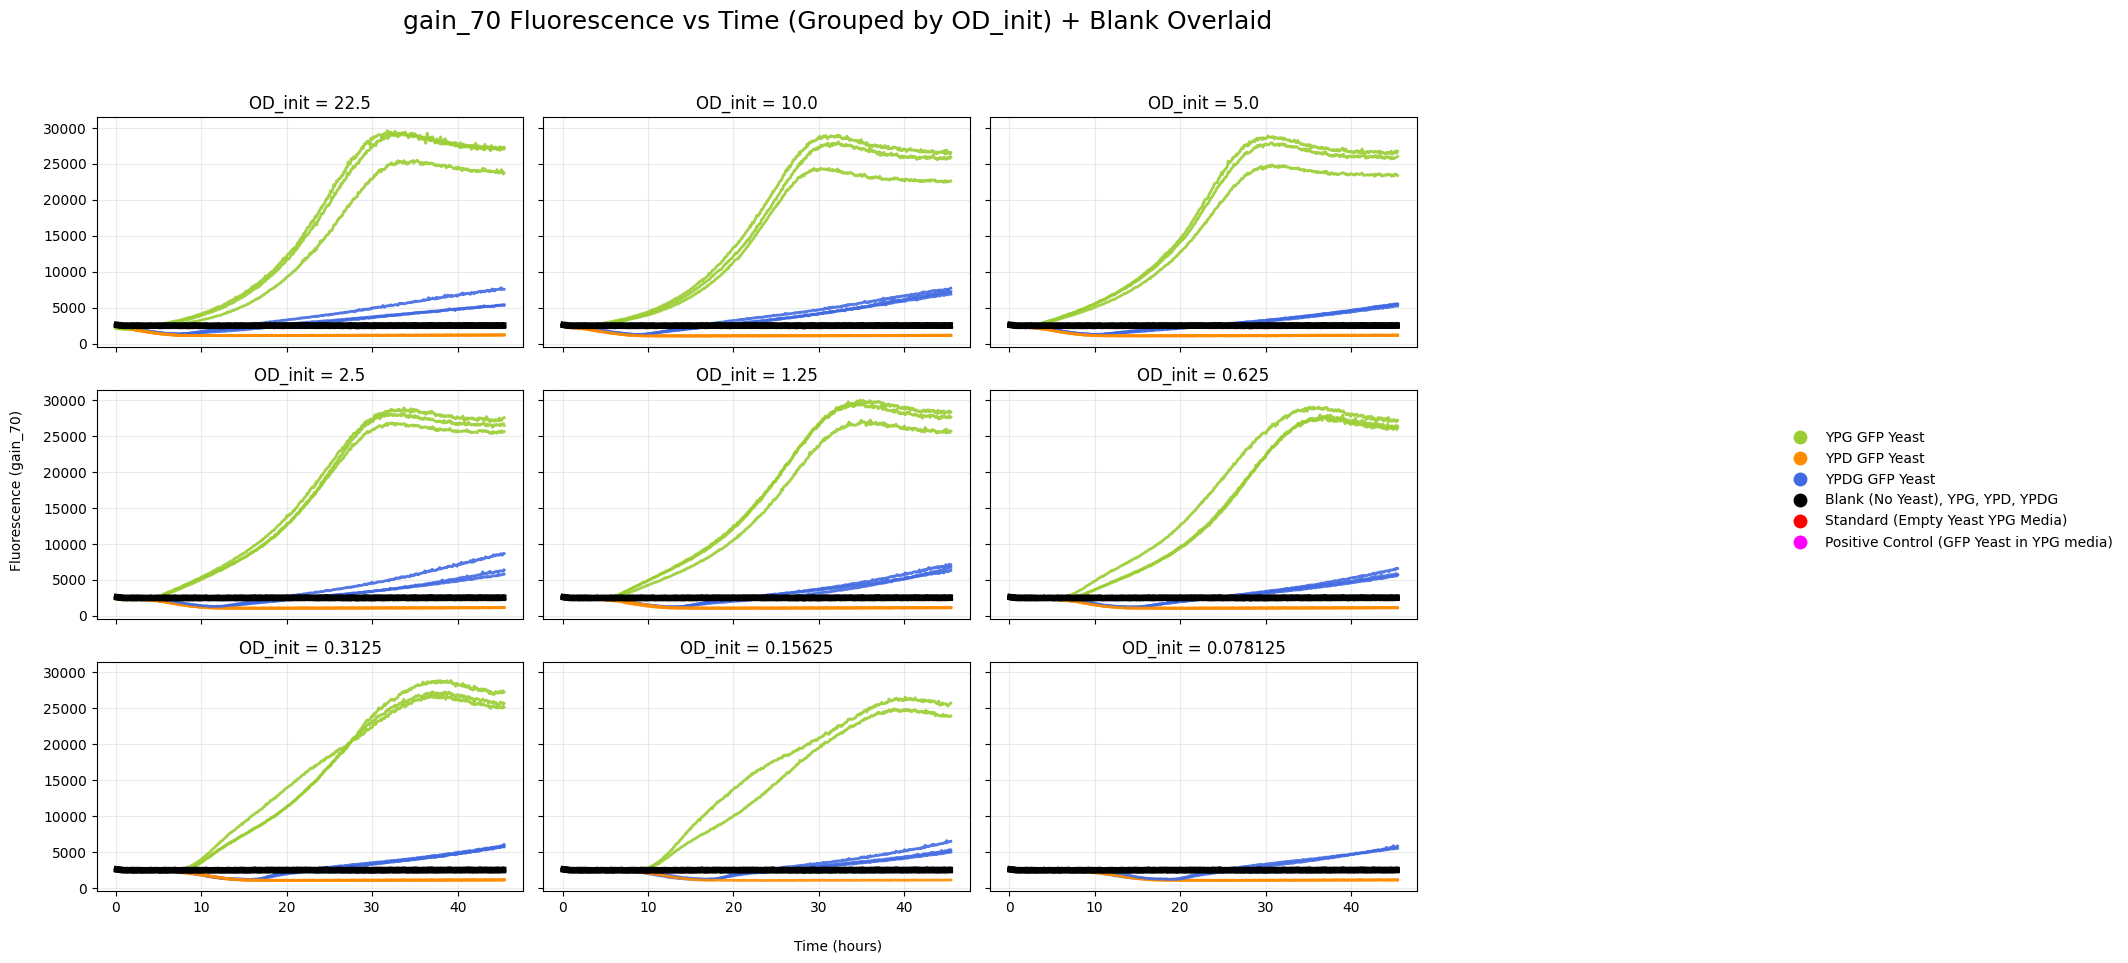

Invalid FL (<=0 or NaN): 3
Invalid OD (<=0 or NaN): 0
Invalid either: 3

Invalid reason counts:
invalid_reason
FL<=0 or NaN    3
Name: count, dtype: int64


,OD_init,mu_max,lag_time,AUC_4h,curvature_4h,outcome_raw,outcome
count,73.000000,73.000000,73.000000,73.000000,73.000000,70.000000,70.000000
mean,5.218322,0.511804,0.734136,0.165233,0.023914,6742.466548,7.036523
std,7.234441,0.109925,0.653884,0.180144,0.028543,7193.274785,2.929982
min,0.078125,0.080313,0.401944,-0.001938,-0.023270,3.072932,1.404363
25%,0.312500,0.482466,0.401944,0.036610,0.007269,49.795031,3.916661
50%,1.250000,0.518230,0.401944,0.079984,0.013488,3253.622179,8.087831
75%,5.000000,0.568640,0.985278,0.234341,0.026596,15965.653364,9.678255
max,22.500000,0.735284,3.651944,0.634096,0.100389,18250.066172,9.811979


In [756]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# A) Wide gain_70 -> long + attach metadata + PLOT (with BLANK overlaid on every subplot)
# ============================================================

# ---- A1) Wide fluorescence -> long ----
well_cols = gain_70.columns[gain_70.columns.str.match(r"^[A-H](?:[1-9]|1[0-2])$")]

fl_long = gain_70[["Time", *well_cols]].melt(
    id_vars="Time", var_name="well", value_name="FL"
)

# convert "Time" to hours
fl_long["Time"] = pd.to_timedelta(fl_long["Time"], errors="coerce").dt.total_seconds() / 3600

# ---- A2) Attach metadata (media + function) ----
fl_long = fl_long.merge(cat[["well", "media_type", "function"]], on="well", how="left")

# ---- A3) Attach OD_init (will be NaN for blanks/standards) ----
fl_plot = fl_long.merge(df_merged[["well", "OD_init"]], on="well", how="left").copy()

# numeric cleanup
fl_plot["FL"] = pd.to_numeric(fl_plot["FL"], errors="coerce")
fl_plot["function_lc"] = fl_plot["function"].astype(str).str.strip().str.lower()
fl_plot["media_type"] = fl_plot["media_type"].astype(str).str.strip().str.upper()

# keep only plot-critical columns
fl_plot = fl_plot.dropna(subset=["Time", "FL", "function", "media_type"]).copy()

# ---- A4) Human-readable labels ----
def pretty_label(func_lc, media):
    if func_lc == "blank":
        return "Blank (No Yeast), YPG, YPD, YPDG"
    if func_lc == "standard":
        return "Standard (Empty Yeast YPG Media)"
    if func_lc in {"positive control", "positive_control", "pos control", "pos_control"}:
        return "Positive Control (GFP Yeast in YPG media)"
    return f"{media} GFP Yeast"

fl_plot["legend_label"] = fl_plot.apply(
    lambda r: pretty_label(r["function_lc"], r["media_type"]),
    axis=1
)

# ---- A5) Split samples vs blank (blank gets overlaid on every subplot) ----
blank_df  = fl_plot[fl_plot["function_lc"] == "blank"].copy()
sample_df = fl_plot[fl_plot["function_lc"] != "blank"].dropna(subset=["OD_init"]).copy()

# choose OD_init levels from samples only
od_levels = sorted(sample_df["OD_init"].unique(), reverse=True)[:9]

# ---- A6) Colors ----
label_colors = {
    "YPG GFP Yeast": "yellowgreen",
    "YPD GFP Yeast": "darkorange",
    "YPDG GFP Yeast": "royalblue",
    "Blank (No Yeast), YPG, YPD, YPDG": "black",
    "Standard (Empty Yeast YPG Media)": "red",
    "Positive Control (GFP Yeast in YPG media)": "magenta",
}

# ---- A7) Plot 3x3 ----
fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.ravel()

for i, od0 in enumerate(od_levels):
    ax = axes[i]

    # samples for this OD_init
    sub = sample_df[sample_df["OD_init"] == od0]
    for well, g in sub.groupby("well"):
        g = g.sort_values("Time")
        lab = g["legend_label"].iloc[0]
        ax.plot(
            g["Time"].to_numpy(),
            g["FL"].to_numpy(),
            linewidth=2,
            alpha=0.9,
            color=label_colors.get(lab, "gray")
        )

    # overlay the SAME blank traces on every subplot
    for well, g in blank_df.groupby("well"):
        g = g.sort_values("Time")
        ax.plot(
            g["Time"].to_numpy(),
            g["FL"].to_numpy(),
            linewidth=3,
            alpha=1.0,
            color=label_colors["Blank (No Yeast), YPG, YPD, YPDG"],
            zorder=10
        )

    ax.set_title(f"OD_init = {od0}", fontsize=12)
    ax.grid(True, alpha=0.25)

# turn off unused axes
for j in range(i + 1, 9):
    axes[j].axis("off")

# ---- A8) Global legend ----
legend_order = [
    "YPG GFP Yeast",
    "YPD GFP Yeast",
    "YPDG GFP Yeast",
    "Blank (No Yeast), YPG, YPD, YPDG",
    "Standard (Empty Yeast YPG Media)",
    "Positive Control (GFP Yeast in YPG media)"
]
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               markersize=10, markerfacecolor=label_colors[l],
               markeredgecolor="none", label=l)
    for l in legend_order if l in label_colors
]

fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

fig.suptitle("gain_70 Fluorescence vs Time (Grouped by OD_init) + Blank Overlaid", fontsize=18, y=0.98)
fig.text(0.5, 0.04, "Time (hours)", ha="center")
fig.text(0.04, 0.5, "Fluorescence (gain_70)", va="center", rotation="vertical")

plt.tight_layout(rect=[0.05, 0.06, 0.83, 0.95])
plt.show()


# ============================================================
# B) Fluorescence STANDARD subtraction ONLY (no baseline, no blanks)
# ============================================================

fl = fl_long.copy()
fl["FL"] = pd.to_numeric(fl["FL"], errors="coerce")

std_ref = (
    fl[fl["function"].astype(str).str.lower().str.strip().eq("standard")]
    .groupby("Time", as_index=False)["FL"]
    .mean()
    .rename(columns={"FL": "FL_std"})
)

fl = fl.merge(std_ref, on="Time", how="left")
fl["FL_corr"] = fl["FL"] - fl["FL_std"]

# NOTE: keep this if you want fluorescence negatives removed BEFORE picking final timepoint
fl["FL_corr"] = pd.to_numeric(fl["FL_corr"], errors="coerce")


# ============================================================
# C) Align to OD end time (earlier stop between FL and OD)
#    + VALIDITY CHECK (FL/OD) with SAFE invalid_reason creation
# ============================================================

# --- OD prep ---
od = abs_long_clean.copy()
od_col = next(c for c in ["OD_smooth", "OD_bs", "OD"] if c in od.columns)

od["Time"] = pd.to_numeric(od["Time"], errors="coerce")
od[od_col] = pd.to_numeric(od[od_col], errors="coerce")

# --- FL prep (make sure time numeric) ---
fl["Time"] = pd.to_numeric(fl["Time"], errors="coerce")
fl["FL_corr"] = pd.to_numeric(fl["FL_corr"], errors="coerce")

# --- per-well end time = min(last FL time, last OD time) ---
end_times = (
    fl.groupby("well", as_index=False)["Time"].max().rename(columns={"Time": "fl_end"})
    .merge(
        od.groupby("well", as_index=False)["Time"].max().rename(columns={"Time": "od_end"}),
        on="well",
        how="inner",
    )
)
end_times["t_end"] = end_times[["fl_end", "od_end"]].min(axis=1)

# --- last fluorescence at/before t_end ---
fl_pick = fl.merge(end_times[["well", "t_end"]], on="well", how="inner")
fl_pick = fl_pick[fl_pick["Time"] <= fl_pick["t_end"]].copy()
idx_fl = fl_pick.groupby("well")["Time"].idxmax()
fl_final = fl_pick.loc[idx_fl, ["well", "FL_corr"]].rename(columns={"FL_corr": "final_fluor_corr"})

# --- last OD at/before t_end ---
od_pick = od.merge(end_times[["well", "t_end"]], on="well", how="inner")
od_pick = od_pick[od_pick["Time"] <= od_pick["t_end"]].copy()
idx_od = od_pick.groupby("well")["Time"].idxmax()
od_final = od_pick.loc[idx_od, ["well", od_col]].rename(columns={od_col: "final_OD"})

# --- merge finals into final_df ---
final_df = (
    end_times[["well", "t_end"]]
    .merge(fl_final, on="well", how="left")
    .merge(od_final, on="well", how="left")
)

# ============================================================
# Validity flags BEFORE ratio (NO dtype mistakes)
# ============================================================

final_df["final_fluor_corr"] = pd.to_numeric(final_df["final_fluor_corr"], errors="coerce")
final_df["final_OD"] = pd.to_numeric(final_df["final_OD"], errors="coerce")

final_df["invalid_FL_le0"] = final_df["final_fluor_corr"].isna() | (final_df["final_fluor_corr"] <= 0)
final_df["invalid_OD_le0"] = final_df["final_OD"].isna() | (final_df["final_OD"] <= 0)

# SAFEST way: build invalid_reason without .loc assignments to a float column
final_df["invalid_reason"] = np.select(
    [
        final_df["invalid_FL_le0"] & final_df["invalid_OD_le0"],
        final_df["invalid_FL_le0"] & ~final_df["invalid_OD_le0"],
        ~final_df["invalid_FL_le0"] & final_df["invalid_OD_le0"],
    ],
    [
        "FL<=0 or NaN AND OD<=0 or NaN",
        "FL<=0 or NaN",
        "OD<=0 or NaN",
    ],
    default=""
)

print("Invalid FL (<=0 or NaN):", int(final_df["invalid_FL_le0"].sum()))
print("Invalid OD (<=0 or NaN):", int(final_df["invalid_OD_le0"].sum()))
print("Invalid either:", int((final_df["invalid_FL_le0"] | final_df["invalid_OD_le0"]).sum()))
print("\nInvalid reason counts:")
print(final_df.loc[final_df["invalid_reason"] != "", "invalid_reason"].value_counts())

# ============================================================
# Compute ratio ONLY where valid
# ============================================================

final_df["outcome_raw"] = np.nan
valid_mask = ~(final_df["invalid_FL_le0"] | final_df["invalid_OD_le0"])
final_df.loc[valid_mask, "outcome_raw"] = (
    final_df.loc[valid_mask, "final_fluor_corr"] / final_df.loc[valid_mask, "final_OD"]
)


# ============================================================
# D) Final outcome + store safely in df_merged
# ============================================================

mapped = df_merged["well"].map(final_df.set_index("well")["outcome_raw"])
df_merged["outcome_raw"] = mapped
df_merged["outcome"] = np.log1p(df_merged["outcome_raw"])

df_merged.describe()

Negative corrected fluorescence values occur when the final fluorescence, after subtracting both the per-well baseline (t₀) and the row-wise media blank, falls slightly below the blank due to experimental noise, background drift, or minor overcorrection.

Biologically, this does not indicate “negative protein production”; rather, it means the expression level is indistinguishable from background and below the detection limit.

Since protein concentration and fluorescence intensity cannot be physically negative, these values do not represent meaningful biological signal.

Instead of forcing them to zero, these wells are excluded from modeling and transformations, as they reflect unreliable measurements rather than true negative expression.

Conceptually, this treats such cases as having no detectable expression while avoiding distortion of the statistical analysis.

## 3. t-SNE 

### 3.1 t-SNE ((colored by High Yield and Low Yield))

Rows after cleaning: 70
High yield threshold (raw): 8.928110078202646
Class balance:
 yield_class
0    47
1    23
Name: count, dtype: int64


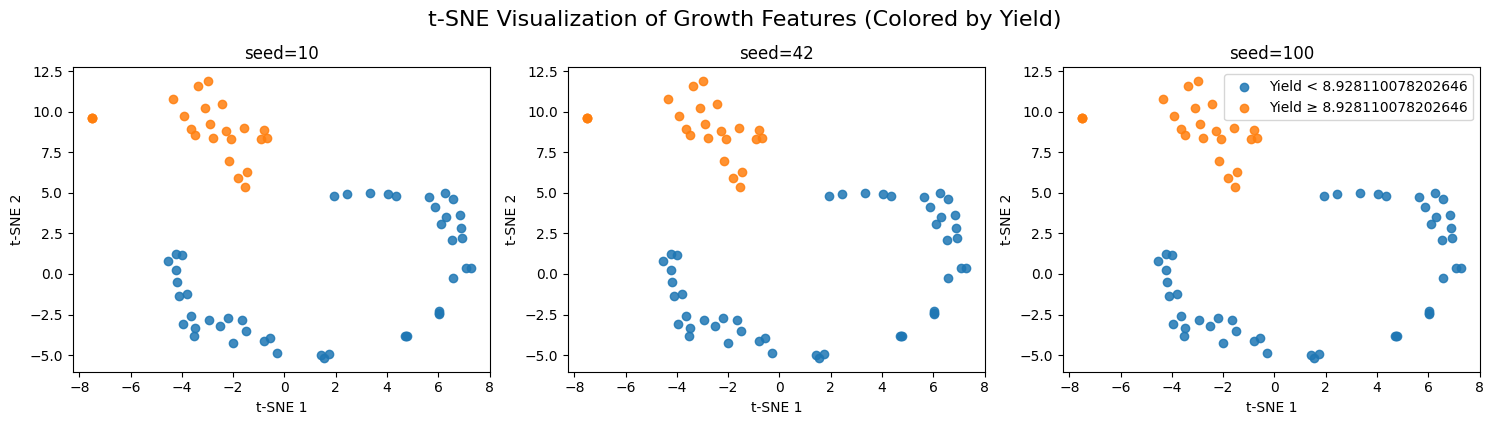

In [743]:
# ============================================================
# t-SNE visualization for your engineered growth features
# - Cleans outcome (drop outcome<=0), recompute log
# - Standardizes features
# - Runs t-SNE in 2D
# - Plots colored by yield_class and (optionally) media_type
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# ----------------------------
# 0) Inputs
# ----------------------------
df = df_merged.copy()

feature_cols = [
    "OD_init",
    "mu_max",
    "lag_time",
    "AUC_4h",
    "curvature_4h",
    "media_type_YPD",
    "media_type_YPDG"
]

MEDIA_COL = "media_type" if "media_type" in df.columns else None

# ----------------------------
# 1) Clean outcome + define y (NO LOG, fixed threshold = 6000)
# ----------------------------
df = df[df["outcome"] > 0].copy()

THRESHOLD = np.log1p(7540)  # log1p of 7540

df["yield_class"] = (df["outcome"] >= THRESHOLD).astype(int)

print("Rows after cleaning:", len(df))
print("High yield threshold (raw):", THRESHOLD)
print("Class balance:\n", df["yield_class"].value_counts())

# ----------------------------
# 2) Standardize X
# ----------------------------
X = df[feature_cols].to_numpy()
Xz = StandardScaler().fit_transform(X)

# ----------------------------
# 3) Choose t-SNE params safely for small n
# ----------------------------
n = len(df)

# Perplexity rule of thumb: < n/3, typically 5–15 for n~45
perplexity = min(15, max(5, (n - 1) // 3))  # auto-ish, safe bounds
learning_rate = "auto"
# Try a few seeds and see if separation is consistent.
seeds = [10, 42, 100]
plt.figure(figsize=(15, 4))

for i, seed in enumerate(seeds, 1):
    tsne_tmp = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        init="pca",
        random_state=seed,
        max_iter=2000
    )
    Ztmp = tsne_tmp.fit_transform(Xz)

    ax = plt.subplot(1, len(seeds), i)

    for cls in sorted(df["yield_class"].unique()):
        m = df["yield_class"] == cls

        if cls == 1:
            label = f"Yield ≥ {THRESHOLD}"
        else:
            label = f"Yield < {THRESHOLD}"

        ax.scatter(
            Ztmp[m, 0],
            Ztmp[m, 1],
            label=label,
            alpha=0.85
        )

    ax.set_title(f"seed={seed}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

# Put ONE shared legend outside the loop
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc="best")
plt.tight_layout()
plt.suptitle("t-SNE Visualization of Growth Features (Colored by Yield)", 
             fontsize=16, 
             y=1.05)
plt.show()



### 3.2 t-SNE (colored by media type)

media_label
YPDG    26
YPG     23
YPD     21
Name: count, dtype: int64


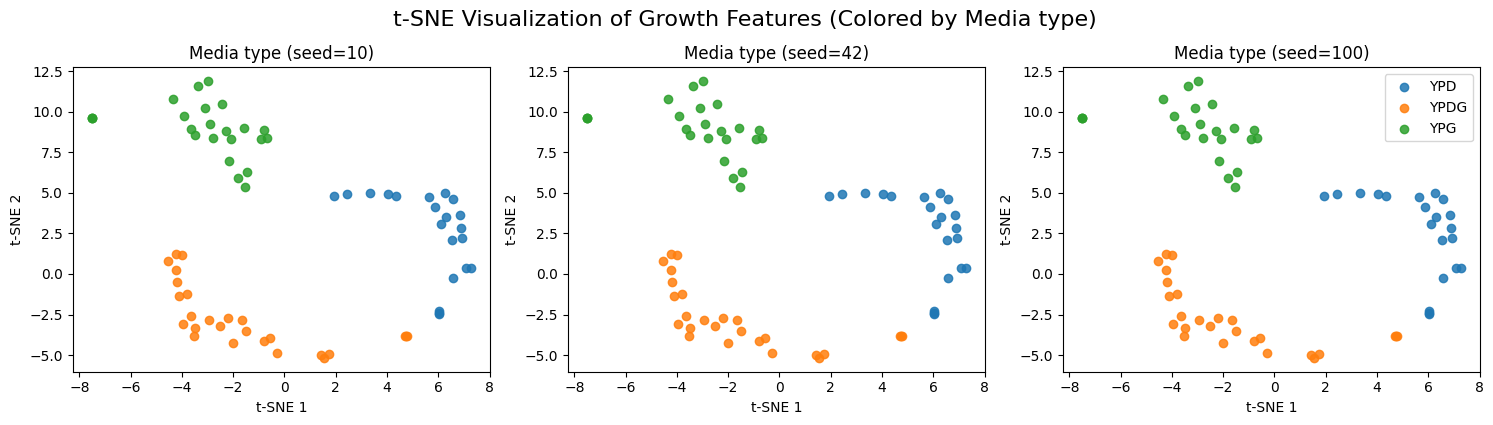

In [744]:
if "media_type" in df.columns:
    df["media_label"] = df["media_type"].astype(str)
else:
    # infer from one-hot (baseline category = YPG if neither YPD nor YPDG)
    def infer_media(row):
        if row.get("media_type_YPD", 0) == 1:
            return "YPD"
        if row.get("media_type_YPDG", 0) == 1:
            return "YPDG"
        return "YPG"  # baseline (adjust if your baseline is different)

    df["media_label"] = df.apply(infer_media, axis=1)

print(df["media_label"].value_counts())

# ----------------------------
# 4) t-SNE params
# ----------------------------
n = len(df)
perplexity = min(15, max(5, (n - 1) // 3))
seeds = [10, 42, 100]

# ----------------------------
# 5) Plot t-SNE colored by media type
# ----------------------------
media_order = sorted(df["media_label"].unique())  # stable ordering for legend

plt.figure(figsize=(15, 4))
for i, seed in enumerate(seeds, 1):
    tsne_tmp = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=seed,
        max_iter=2000
    )
    Z = tsne_tmp.fit_transform(Xz)

    ax = plt.subplot(1, len(seeds), i)
    for med in media_order:
        m = (df["media_label"] == med).to_numpy()
        ax.scatter(Z[m, 0], Z[m, 1], label=med, alpha=0.85)

    ax.set_title(f"Media type (seed={seed})")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

# one shared legend (from the last axis)
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc="best")
plt.tight_layout()
plt.suptitle("t-SNE Visualization of Growth Features (Colored by Media type)", 
             fontsize=16, 
             y=1.05)
plt.show()

## 4. Modelling

In [745]:
# Target
y = df_merged["outcome"].astype(float)

# Feature columns: new engineered features
base_feats = ["OD_init", "mu_max", "lag_time", "AUC_4h", "curvature_4h"]

# Media one-hot columns (works regardless of how many you have)
media_feats = [c for c in df_merged.columns if c.startswith("media_type_")]

features= base_feats + media_feats
# Final X
X = df_merged[features].copy()

# Convert True/False -> 0/1 (important for many models)
X[media_feats] = X[media_feats].astype(int)

mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 4.1 Symbolic Regression

In [746]:
# Build basis library and fit symbolic regression model
basis = BasisLibrary(len(features), feature_names=features)
basis.add_constant()
basis.add_linear()
basis.add_polynomials(max_degree=3)
basis.add_interactions()

sr = SymbolicRegressor(basis, max_terms=10, strategy="greedy_forward",
                       information_criterion="bic")
sr.fit(X_train, y_train)

print("Discovered expression:")
print(sr.expression_)
print()
y_pred_sr = sr.predict(X_test)
r2_sr = r2_score(y_test, y_pred_sr)
mse_sr = mean_squared_error(y_test, y_pred_sr)

print(f"Symbolic Regression  R² = {r2_sr:.4f},  MSE = {mse_sr:.4f}")
print(f"  Training R²: {sr.score(X_train, y_train):.4f}")
print(f"  Test R²: {sr.score(X_test, y_test):.4f}")
print(f"  Gap: {sr.score(X_train, y_train) - sr.score(X_test, y_test):.4f}")


Discovered expression:
y = 9.721 - 4.433*mu_max*media_type_YPD - 1.633*media_type_YPDG - 5.724*media_type_YPD + 0.09097*OD_init*media_type_YPD + 0.3117*lag_time*media_type_YPD

Symbolic Regression  R² = 0.9461,  MSE = 0.5704
  Training R²: 0.9785
  Test R²: 0.9461
  Gap: 0.0324


The symbolic regression model behaves differently depending on the media type, meaning the equation effectively changes structure across conditions rather than applying one uniform relationship.

The model exhibits structural sparsity, as most potential relationships between growth features and yield are set to zero, and only a small subset of interactions are retained.

In YPD, protein yield depends on growth kinetics, as μ_max, lag_time, and OD_init all directly influence the predicted outcome.

This indicates that under YPD conditions, protein production is growth-coupled, and variations in growth behavior meaningfully impact yield.

In YPDG, protein yield does not depend on μ_max, lag_time, or OD_init, and instead shifts by a constant amount relative to the baseline.

This suggests that under YPDG conditions, protein yield is largely growth-independent and not driven by kinetic differences between wells.

In YPG, which serves as the reference media, protein yield remains constant and shows no dependence on growth features.

Overall, the model suggests that media type acts as a structural gate that determines whether growth kinetics influence protein yield or whether yield remains baseline-constrained.

### 4.2 Random Forest and XGBoost

Random Forest Test R²: 0.9500
XGBoost Test R²: 0.9506


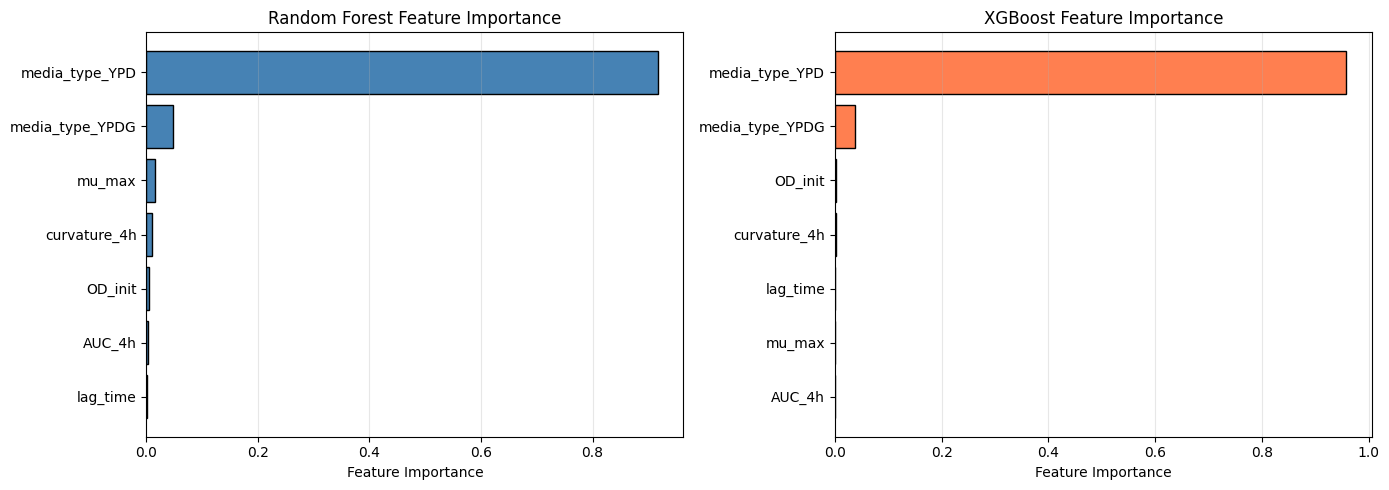

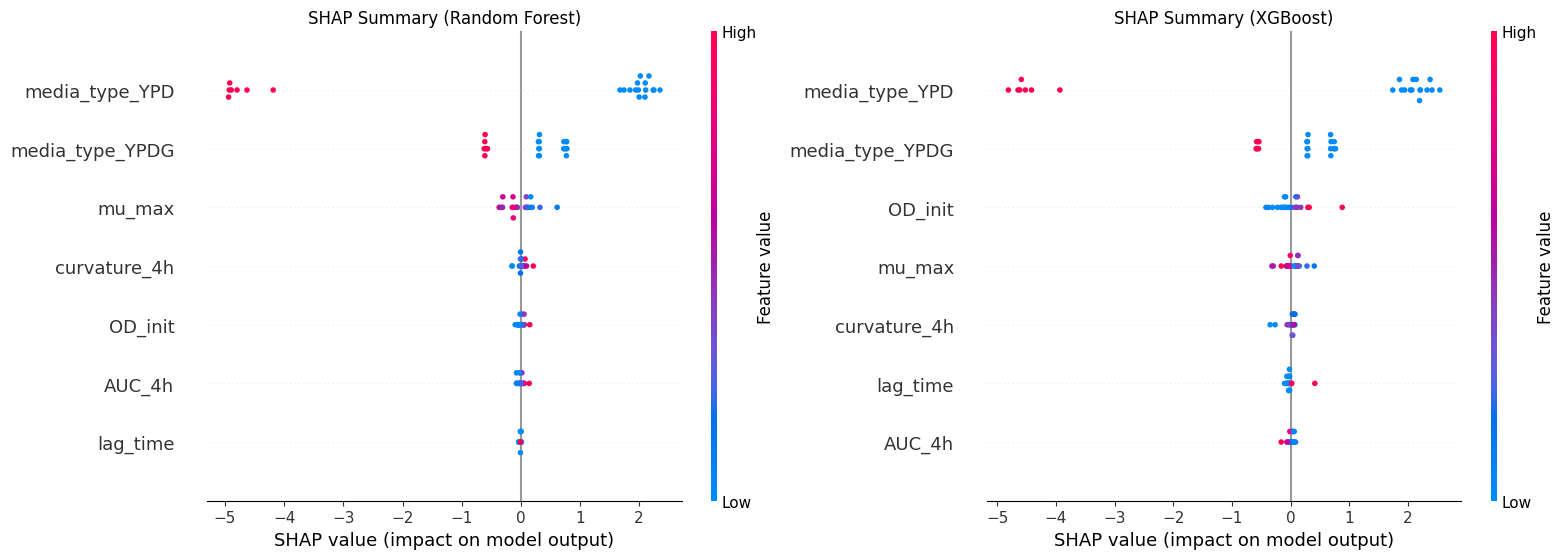

In [747]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

print(f"Random Forest Test R²: {rf.score(X_test, y_test):.4f}")
print(f"XGBoost Test R²: {xgb_model.score(X_test, y_test):.4f}")

# Feature importance from Random Forest
importance_rf = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
axes[0].barh(importance_rf['Feature'], importance_rf['Importance'], 
             edgecolor='black', color='steelblue')
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('Random Forest Feature Importance')
axes[0].grid(True, alpha=0.3, axis='x')

# XGBoost
importance_xgb = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(importance_xgb['Feature'], importance_xgb['Importance'], 
             edgecolor='black', color='coral')
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('XGBoost Feature Importance')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ---- Compute SHAP values ----
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_xgb = explainer_xgb.shap_values(X_test)

explainer_rf = shap.TreeExplainer(rf)
shap_rf = explainer_rf.shap_values(X_test)

# ---- Create subplots ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- XGBoost ----
plt.sca(axes[1])
shap.summary_plot(
    shap_xgb,
    X_test,
    feature_names=features,
    show=False,
    plot_size=None  # important
)
axes[1].set_title("SHAP Summary (XGBoost)")

# ---- Random Forest ----
plt.sca(axes[0])
shap.summary_plot(
    shap_rf,
    X_test,
    feature_names=features,
    show=False,
    plot_size=None  # also important
)
axes[0].set_title("SHAP Summary (Random Forest)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 4.2 Cross validation to prevent overfitting

In [748]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

class SklearnSymbolicRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, features, max_degree=3, max_terms=10,
                 strategy="greedy_forward", information_criterion="bic"):
        self.features = features
        self.max_degree = max_degree
        self.max_terms = max_terms
        self.strategy = strategy
        self.information_criterion = information_criterion

    def fit(self, X, y):
        basis = (
            BasisLibrary(n_features=len(self.features),
                         feature_names=self.features)
            .add_constant()
            .add_linear()
            .add_polynomials(max_degree=self.max_degree)
            .add_interactions(max_order=2)
        )

        self.model_ = SymbolicRegressor(
            basis_library=basis,
            max_terms=self.max_terms,
            strategy=self.strategy,
            information_criterion=self.information_criterion
        )

        self.model_.fit(X, y)
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def score(self, X, y):
        return self.model_.score(X, y)
model = SklearnSymbolicRegressor(
    features=features,
    max_degree=3,
    max_terms=10
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=cv, scoring="r2")

print("CV R² scores:", scores)
print("Mean R²:", np.mean(scores))


CV R² scores: [0.95320136 0.89721189 0.94753297 0.98743375 0.98042373]
Mean R²: 0.9531607386155138


### 4.3 Ucertainty Quantification

Nonlinear Regression Results (95% CI):
  p0 = 9.721 ± 0.2547   (SE=0.1264)
  p1 = -5.724 ± 2.006   (SE=0.9958)
  p2 = -1.633 ± 0.3407   (SE=0.1691)
  p3 = 0.09097 ± 0.037   (SE=0.01837)
  p4 = 0.3117 ± 0.3034   (SE=0.1507)
  p5 = -4.433 ± 3.701   (SE=1.838)
Total test points: 22
Valid points plotted: 22
Dropped (NaN/inf): 0


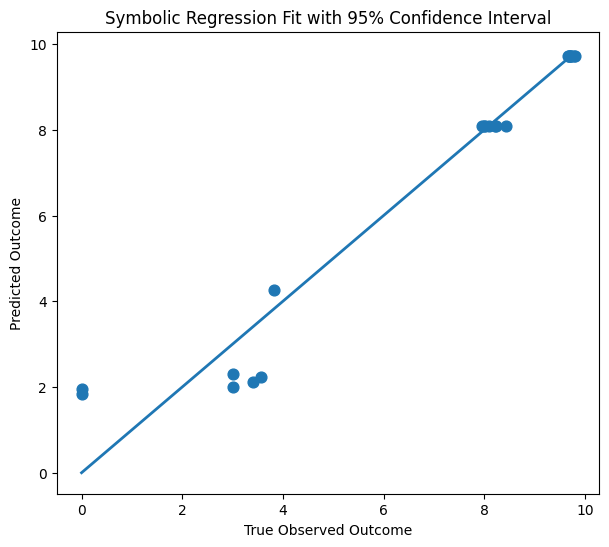

In [749]:
import re
import numpy as np
import sympy as sp
from pycse import nlinfit
import matplotlib.pyplot as plt

# --- Clean expression ---
expr_str = sr.expression_.strip()
expr_str = re.sub(r"^\s*y\s*=\s*", "", expr_str)

# --- Make sure X/y are numpy for nlinfit ---
Xtr = np.asarray(X_train, dtype=float)
ytr = np.asarray(y_train, dtype=float).ravel()
Xte = np.asarray(X_test, dtype=float)
yte = np.asarray(y_test, dtype=float).ravel()

# --- Sympy parse using your feature names ---
xs = sp.symbols(features)
xmap = {name: sym for name, sym in zip(features, xs)}

expr = sp.expand(sp.sympify(expr_str, locals=xmap))
terms = sp.Add.make_args(expr)

phis, p0 = [], []
for t in terms:
    coeff, rest = t.as_coeff_Mul()
    phis.append(sp.simplify(rest))
    p0.append(float(coeff))
p0 = np.array(p0, dtype=float)

phi_fns = [sp.lambdify(xs, phi, "numpy") for phi in phis]

def symbolic_model(X, *p):
    cols = [X[:, j] for j in range(X.shape[1])]
    yhat = np.zeros(X.shape[0], dtype=float)
    for pj, phi_fn in zip(p, phi_fns):
        yhat += pj * np.asarray(phi_fn(*cols), dtype=float)
    return yhat

# --- nlinfit with uncertainty (like your screenshot) ---
p, pint, se = nlinfit(symbolic_model, Xtr, ytr, p0, alpha=0.05)

print("Nonlinear Regression Results (95% CI):")
for j in range(len(p)):
    half_width = (pint[j, 1] - pint[j, 0]) / 2
    print(f"  p{j} = {p[j]:.4g} ± {half_width:.4g}   (SE={se[j]:.4g})")

# --- Plot predicted vs true (multi-feature equivalent of his curve plot) ---
y_pred = symbolic_model(Xte, *p)

# --- Count how many valid points will be plotted ---
mask = np.isfinite(yte) & np.isfinite(y_pred)

n_total = len(yte)
n_plotted = np.sum(mask)

print(f"Total test points: {n_total}")
print(f"Valid points plotted: {n_plotted}")
print(f"Dropped (NaN/inf): {n_total - n_plotted}")

plt.figure(figsize=(7,6))
plt.scatter(yte, y_pred, s=60, zorder=5)
mn = min(yte.min(), y_pred.min())
mx = max(yte.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], linewidth=2)
plt.xlabel("True Observed Outcome")
plt.ylabel("Predicted Outcome")
plt.title("Symbolic Regression Fit with 95% Confidence Interval")
plt.show()



Fitted params [b0,b1,b2,b3]: [ 9.62947716 -6.90210819 -1.57642023  0.02082215]
95% CI (rows=b0..b3):
 [[ 9.40482905e+00  9.85412528e+00]
 [-7.19942805e+00 -6.60478834e+00]
 [-1.85957708e+00 -1.29326338e+00]
 [-8.12469669e-04  4.24567747e-02]]


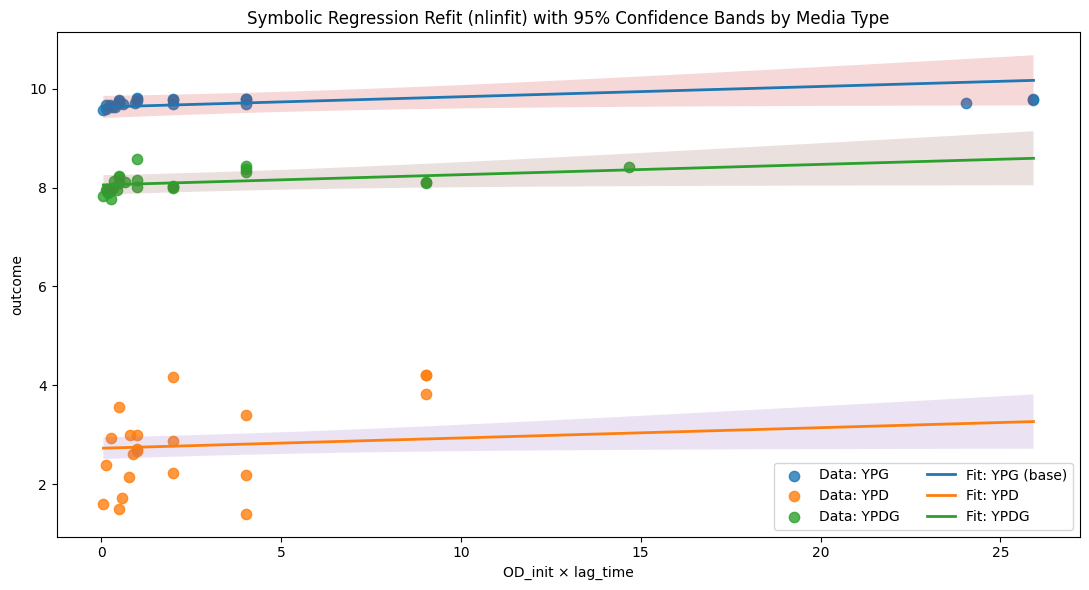

In [750]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pycse import nlinfit

# ----------------------------
# 0) Data
# ----------------------------
df = df_merged.copy()
df = df[df["outcome"] > 0].copy()   # optional, keep if you want

y = df["outcome"].to_numpy(float)

m_ypd  = df["media_type_YPD"].to_numpy(float)
m_ypdg = df["media_type_YPDG"].to_numpy(float)
z = (df["OD_init"].to_numpy(float) * df["lag_time"].to_numpy(float))

# Design matrix: [1, YPD_dummy, YPDG_dummy, OD_init*lag_time]
X = np.column_stack([np.ones(len(df)), m_ypd, m_ypdg, z])

# ----------------------------
# 1) nlinfit refit (same structure, refit coefficients only)
# ----------------------------
def sr_linear(X, b0, b1, b2, b3):
    return X @ np.array([b0, b1, b2, b3], dtype=float)

p0 = np.array([2.4873e4, -2.4949e4, -1.9904e4, 47.61], dtype=float)

p, pint, se = nlinfit(sr_linear, X, y, p0, alpha=0.05)
print("Fitted params [b0,b1,b2,b3]:", p)
print("95% CI (rows=b0..b3):\n", pint)

# ----------------------------
# 2) Teacher-style CI ingredients
# ----------------------------
n = len(y)
k = X.shape[1]
dof = n - k
t_val = stats.t.ppf(0.975, dof)

residuals = y - (X @ p)
mse = np.sum(residuals**2) / dof

XtX_inv = np.linalg.inv(X.T @ X)

# Helper: prediction + CI half-width for ANY X_plot
def pred_and_ci(X_plot):
    y_pred = X_plot @ p
    se_pred = np.sqrt(mse * np.array([x @ XtX_inv @ x for x in X_plot]))
    ci = t_val * se_pred
    return y_pred, ci

# ----------------------------
# 3) Make a common z grid and build X_plot for each media type
# ----------------------------
z_plot = np.linspace(z.min(), z.max(), 250)

media_specs = {
    "YPG (base)":  (0.0, 0.0),
    "YPD":         (1.0, 0.0),
    "YPDG":        (0.0, 1.0),
}

# ----------------------------
# 4) Plot: points + 3 curves + 3 CI bands
# ----------------------------
plt.figure(figsize=(11, 6))

# (optional) scatter with different markers per media, using your dummies
mask_ypg  = (m_ypd == 0) & (m_ypdg == 0)
mask_ypd  = (m_ypd == 1)
mask_ypdg = (m_ypdg == 1)

plt.scatter(z[mask_ypg],  y[mask_ypg],  s=55, alpha=0.8, label="Data: YPG")
plt.scatter(z[mask_ypd],  y[mask_ypd],  s=55, alpha=0.8, label="Data: YPD")
plt.scatter(z[mask_ypdg], y[mask_ypdg], s=55, alpha=0.8, label="Data: YPDG")

# curves + bands
for name, (d_ypd, d_ypdg) in media_specs.items():
    X_plot = np.column_stack([
        np.ones(len(z_plot)),
        np.full(len(z_plot), d_ypd),
        np.full(len(z_plot), d_ypdg),
        z_plot
    ])
    y_pred, ci = pred_and_ci(X_plot)

    plt.plot(z_plot, y_pred, linewidth=2, label=f"Fit: {name}")
    plt.fill_between(z_plot, y_pred - ci, y_pred + ci, alpha=0.18)

plt.xlabel("OD_init × lag_time")
plt.ylabel("outcome")
plt.title("Symbolic Regression Refit (nlinfit) with 95% Confidence Bands by Media Type")
plt.legend(ncols=2)
plt.tight_layout()
plt.show()